# Task 3: Anomaly Detection — Instrument Failure Detection

Detect instrument anomalies for 6 station/pollutant/period combinations.

**Approach**: Isolation Forest trained on labeled historical data, then applied to unlabeled target periods. Validated on a holdout period with known labels.

**Key insight**: Target periods have no instrument_status labels (all NULL). We train on earlier labeled data and predict anomalies in the target periods.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.loader import load_full_series, load_series
from src.anomaly.detector import (
    train_anomaly_detector, predict_anomalies,
    evaluate_anomaly_detection, build_anomaly_features
)
from src.utils.constants import ANOMALY_TARGETS

print(f"Anomaly detection targets: {len(ANOMALY_TARGETS)}")
for t in ANOMALY_TARGETS:
    print(f"  Station {t['station_code']} / {t['item_name']} / {t['start']} to {t['end']}")

Anomaly detection targets: 6
  Station 205 / so2 / 2023-11-01 to 2023-11-30 23:00:00
  Station 209 / no2 / 2023-09-01 to 2023-09-30 23:00:00
  Station 223 / o3 / 2023-07-01 to 2023-07-31 23:00:00
  Station 224 / co / 2023-10-01 to 2023-10-31 23:00:00
  Station 226 / pm10 / 2023-08-01 to 2023-08-31 23:00:00
  Station 227 / pm2.5 / 2023-12-01 to 2023-12-31 23:00:00


## Validation and Prediction

For each target:
1. Load full series (all statuses) up to the target period
2. Split: train on earlier labeled data, validate on last labeled month
3. Train Isolation Forest, evaluate on validation
4. Retrain on all labeled data, predict anomalies in target period

In [2]:
results = []
all_anomaly_preds = {}

for target in ANOMALY_TARGETS:
    sc = target["station_code"]
    ic = target["item_code"]
    name = target["item_name"]
    pred_start = target["start"]
    pred_end = target["end"]
    
    print(f"\n{'='*60}")
    print(f"Station {sc} / {name} | Detect anomalies: {pred_start} to {pred_end}")
    print(f"{'='*60}")
    
    # Load full series (all statuses)
    full_series = load_full_series(sc, ic)
    
    # Split: labeled data (has instrument_status) vs target (NULL status)
    labeled = full_series[full_series["instrument_status"].notna()].copy()
    target_data = full_series[
        (full_series.index >= pred_start) & (full_series.index <= pred_end)
    ].copy()
    
    # Handle -1 values
    labeled["clean_value"] = labeled["clean_value"].ffill().bfill()
    target_data["clean_value"] = target_data["clean_value"].ffill().bfill()
    
    # Compute contamination from labeled data
    anomaly_rate = (labeled["instrument_status"] != 0).mean()
    contamination = max(anomaly_rate, 0.01)  # At least 1%
    
    print(f"Labeled data: {len(labeled)} rows, anomaly rate: {anomaly_rate:.3f}")
    print(f"Target data: {len(target_data)} rows (no labels)")
    
    # --- Validation: hold out last month of labeled data ---
    val_start = labeled.index.max() - pd.DateOffset(months=1) + pd.Timedelta(hours=1)
    train_data = labeled.loc[:val_start - pd.Timedelta(hours=1)]
    val_data = labeled.loc[val_start:]
    
    print(f"Training: {len(train_data)} rows | Validation: {len(val_data)} rows")
    
    # Train and evaluate on validation
    model, scaler, feat_cols = train_anomaly_detector(
        train_data[["clean_value"]], contamination=contamination
    )
    val_preds = predict_anomalies(model, scaler, val_data[["clean_value"]], feat_cols)
    
    if val_data["instrument_status"].notna().any():
        val_metrics = evaluate_anomaly_detection(
            val_data["instrument_status"], val_preds["predicted_status"]
        )
        print(f"\nValidation F1 (anomaly): {val_metrics['f1_anomaly']:.3f}")
        print(f"True anomalies: {val_metrics['n_true_anomalies']}, "
              f"Predicted: {val_metrics['n_predicted_anomalies']}")
        print(val_metrics["report"])
    else:
        val_metrics = {"f1_anomaly": None, "n_true_anomalies": 0, "n_predicted_anomalies": 0}
        print("No labeled anomalies in validation period")
    
    # --- Final: retrain on all labeled data, predict target period ---
    model_final, scaler_final, feat_cols_final = train_anomaly_detector(
        labeled[["clean_value"]], contamination=contamination
    )
    target_preds = predict_anomalies(
        model_final, scaler_final, target_data[["clean_value"]], feat_cols_final
    )
    
    n_detected = target_preds["is_anomaly"].sum()
    print(f"\nTarget period: {n_detected} anomalies detected out of {len(target_preds)} hours "
          f"({n_detected/len(target_preds)*100:.1f}%)")
    
    results.append({
        "station": sc,
        "pollutant": name,
        "period": f"{pred_start} to {pred_end}",
        "labeled_anomaly_rate": round(anomaly_rate * 100, 1),
        "val_f1": val_metrics.get("f1_anomaly"),
        "target_anomalies_detected": int(n_detected),
        "target_total_hours": len(target_preds),
        "target_anomaly_rate_%": round(n_detected / len(target_preds) * 100, 1),
    })
    
    all_anomaly_preds[f"{sc}_{name}"] = {
        "target_predictions": target_preds,
        "val_predictions": val_preds,
        "val_actual": val_data["instrument_status"],
        "target_data": target_data,
    }

print("\n\nAll targets processed.")


Station 205 / so2 | Detect anomalies: 2023-11-01 to 2023-11-30 23:00:00
Labeled data: 24453 rows, anomaly rate: 0.007
Target data: 720 rows (no labels)
Training: 23709 rows | Validation: 744 rows



Validation F1 (anomaly): 0.500
True anomalies: 4, Predicted: 4
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       716
     Anomaly       0.50      0.50      0.50         4

    accuracy                           0.99       720
   macro avg       0.75      0.75      0.75       720
weighted avg       0.99      0.99      0.99       720




Target period: 3 anomalies detected out of 696 hours (0.4%)

Station 209 / no2 | Detect anomalies: 2023-09-01 to 2023-09-30 23:00:00
Labeled data: 23057 rows, anomaly rate: 0.020
Target data: 652 rows (no labels)
Training: 22317 rows | Validation: 740 rows



Validation F1 (anomaly): 0.000
True anomalies: 3, Predicted: 2
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       713
     Anomaly       0.00      0.00      0.00         3

    accuracy                           0.99       716
   macro avg       0.50      0.50      0.50       716
weighted avg       0.99      0.99      0.99       716




Target period: 362 anomalies detected out of 628 hours (57.6%)

Station 223 / o3 | Detect anomalies: 2023-07-01 to 2023-07-31 23:00:00
Labeled data: 21593 rows, anomaly rate: 0.009
Target data: 723 rows (no labels)
Training: 20849 rows | Validation: 744 rows


...


Target period: 10 anomalies detected out of 720 hours (1.4%)

Station 226 / pm10 | Detect anomalies: 2023-08-01 to 2023-08-31 23:00:00
Labeled data: 22316 rows, anomaly rate: 0.028
Target data: 740 rows (no labels)
Training: 21593 rows | Validation: 723 rows



Validation F1 (anomaly): 0.133
True anomalies: 14, Predicted: 1
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       685
     Anomaly       1.00      0.07      0.13        14

    accuracy                           0.98       699
   macro avg       0.99      0.54      0.56       699
weighted avg       0.98      0.98      0.97       699




Target period: 23 anomalies detected out of 716 hours (3.2%)

Station 227 / pm2.5 | Detect anomalies: 2023-12-01 to 2023-12-31 23:00:00
Labeled data: 25173 rows, anomaly rate: 0.038
Target data: 732 rows (no labels)
Training: 24429 rows | Validation: 744 rows



Validation F1 (anomaly): 0.529
True anomalies: 11, Predicted: 23
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       709
     Anomaly       0.39      0.82      0.53        11

    accuracy                           0.98       720
   macro avg       0.69      0.90      0.76       720
weighted avg       0.99      0.98      0.98       720




Target period: 14 anomalies detected out of 708 hours (2.0%)


All targets processed.


## Results Summary

In [3]:
results_df = pd.DataFrame(results)
print("Anomaly Detection Results:")
print(results_df.to_string(index=False))

Anomaly Detection Results:
 station pollutant                            period  labeled_anomaly_rate   val_f1  target_anomalies_detected  target_total_hours  target_anomaly_rate_%
     205       so2 2023-11-01 to 2023-11-30 23:00:00                   0.7 0.500000                          3                 696                    0.4
     209       no2 2023-09-01 to 2023-09-30 23:00:00                   2.0 0.000000                        362                 628                   57.6
     223        o3 2023-07-01 to 2023-07-31 23:00:00                   0.9 0.666667                          7                 699                    1.0
     224        co 2023-10-01 to 2023-10-31 23:00:00                   4.5 0.028662                         10                 720                    1.4
     226      pm10 2023-08-01 to 2023-08-31 23:00:00                   2.8 0.133333                         23                 716                    3.2
     227     pm2.5 2023-12-01 to 2023-12-31 23:00

## Visualization: Anomaly Scores in Target Periods

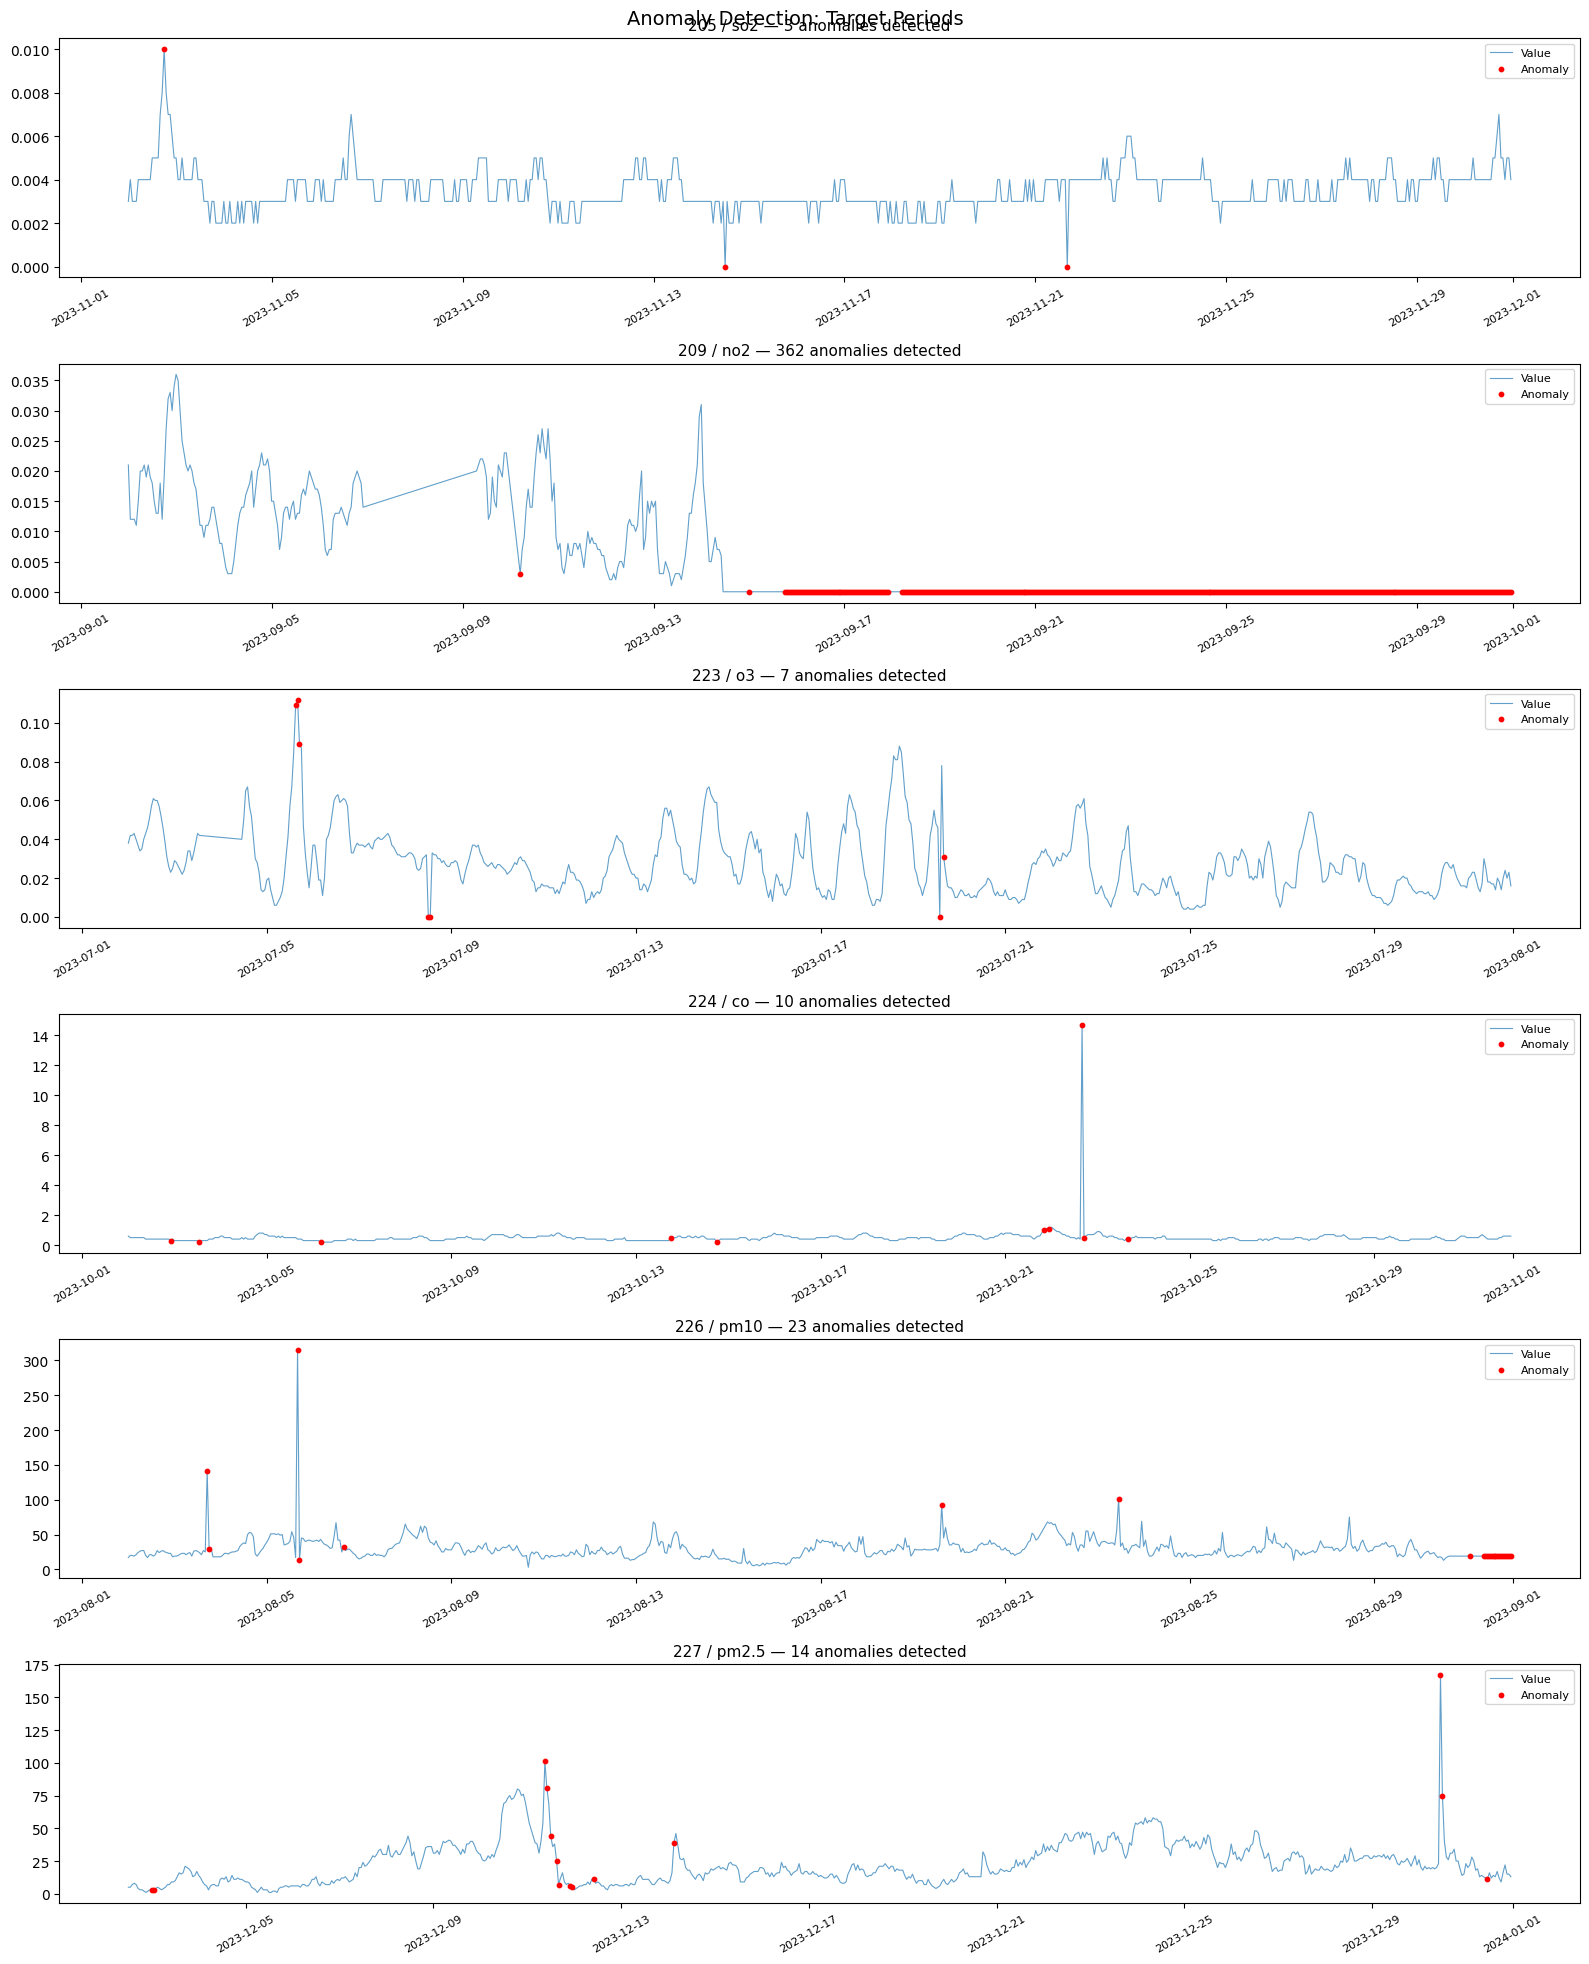

In [4]:
# Plot anomaly scores and detected anomalies for each target
fig, axes = plt.subplots(6, 1, figsize=(16, 20))

for i, (key, data) in enumerate(all_anomaly_preds.items()):
    ax = axes[i]
    target_preds = data["target_predictions"]
    target_data = data["target_data"]
    
    # Plot values
    values = target_data.loc[target_preds.index, "clean_value"]
    ax.plot(values.index, values.values, linewidth=0.8, alpha=0.7, label="Value")
    
    # Highlight anomalies
    anomalies = target_preds[target_preds["is_anomaly"]]
    if len(anomalies) > 0:
        anom_values = values.loc[anomalies.index]
        ax.scatter(anom_values.index, anom_values.values, color="red", s=10, zorder=5, label="Anomaly")
    
    ax.set_title(f"{key.replace('_', ' / ')} — {len(anomalies)} anomalies detected", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle("Anomaly Detection: Target Periods", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()

## Export Anomaly Predictions

In [5]:
import os
os.makedirs("../outputs", exist_ok=True)

all_exports = []
for target in ANOMALY_TARGETS:
    key = f"{target['station_code']}_{target['item_name']}"
    preds = all_anomaly_preds[key]["target_predictions"]
    df = pd.DataFrame({
        "measurement_datetime": preds.index,
        "station_code": target["station_code"],
        "item_code": target["item_code"],
        "item_name": target["item_name"],
        "is_anomaly": preds["is_anomaly"].astype(int),
        "anomaly_score": preds["anomaly_score"].round(5),
    })
    all_exports.append(df)

export_df = pd.concat(all_exports, ignore_index=True)
export_df.to_csv("../outputs/anomaly_predictions.csv", index=False)
print(f"Exported {len(export_df)} predictions to outputs/anomaly_predictions.csv")
print(f"\nAnomaly counts per target:")
print(export_df.groupby(["station_code", "item_name"])["is_anomaly"].agg(["sum", "count"]).to_string())

Exported 4167 predictions to outputs/anomaly_predictions.csv

Anomaly counts per target:
                        sum  count
station_code item_name            
205          so2          3    696
209          no2        362    628
223          o3           7    699
224          co          10    720
226          pm10        23    716
227          pm2.5       14    708
